# Parameters

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd

# ===== CONFIGURAÇÃO DE CAMINHOS =====
current_notebook = Path.cwd()  
project_root = current_notebook.parent.parent 

# Adiciona o diretório raiz ao sys.path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Adiciona o diretório Modules ao sys.path
modules_dir = project_root / "Modules"
if str(modules_dir) not in sys.path:
    sys.path.insert(0, str(modules_dir))

# ===== IMPORTS DOS MÓDULOS =====
import Modules.ClusterKmeansModule as cluster
import Modules.FutureAnalysisModule as fa
from Modules.config import CONFIG

# ===== CONFIGURAÇÕES DO PROJETO =====
DATAPATH = CONFIG["datapath"]
COVID_TRAIN_DATA_FILE = CONFIG["covid_train_data_file"]
COVID_TEST_DATA_FILE = CONFIG["covid_test_data_file"]
FUTURE_DATA_FILE = CONFIG["future_data_file"]

CONTROL_GROUP_TRAIN = CONFIG["control_group_train"]
CONTROL_GROUP_TEST = CONFIG["control_group_test"]
CONTROL_GROUP_READMISSION = CONFIG["control_group_readmission"]

FIGSIZE_CLUSTER_HEATMAP = CONFIG["figsize_cluster_heatmap"]
FIGSIZE_FUTURE_HEATMAP = CONFIG["figsize_future_heatmap"]
IMAGES_SAVE_PATH = CONFIG["image_save_path"]

# Import data

In [2]:
# ===== CARREGAMENTO DOS DADOS =====
data_folder = current_notebook / DATAPATH

covid_train = pd.read_csv(data_folder / COVID_TRAIN_DATA_FILE)
covid_test = pd.read_csv(data_folder / COVID_TEST_DATA_FILE)
future_data = pd.read_csv(data_folder / FUTURE_DATA_FILE)

control_train = pd.read_csv(data_folder / CONTROL_GROUP_TRAIN)
control_test = pd.read_csv(data_folder / CONTROL_GROUP_TEST)
control = pd.concat([control_train, control_test], axis=0)
control_readmission = pd.read_csv(data_folder / CONTROL_GROUP_READMISSION)

# Feature engineering: morte após a internação
covid_train['died_after'] = ((covid_train['died'] == 1) & (covid_train['died_in_stay'] == 0)).astype(int)
covid_test['died_after'] = ((covid_test['died'] == 1) & (covid_test['died_in_stay'] == 0)).astype(int)
future_data['died_after'] = ((future_data['died'] == 1) & (future_data['died_in_stay'] == 0)).astype(int)

In [3]:
data_covid = pd.concat([covid_train, covid_test], axis=0)
data_covid = data_covid.sample(frac=1, random_state=42).reset_index(drop=True)

# Mice Data

In [4]:
categorical_features = [
            "myocardial_infarct",
            "congestive_heart_failure",
            "peripheral_vascular_disease",
            "cerebrovascular_disease",
            "dementia",
            "chronic_pulmonary_disease",
            "rheumatic_disease",
            "peptic_ulcer_disease",
            "mild_liver_disease",
            "diabetes_without_cc",
            "diabetes_with_cc",
            "paraplegia",
            "renal_disease",
            "malignant_cancer",
            "severe_liver_disease",
            "metastatic_solid_tumor",
            "aids",
            "gender_M",
            "died_in_stay",
            "died_after",
            "died",
            "COVID"
        ]

In [5]:
features_not_considered = ["died", "died_in_stay", "died_after", "COVID", "subject_id", "hadm_id"]

In [6]:
helper = cluster.KmeansClusterHelper(data=data_covid, features_not_considered=features_not_considered, scaler= "standard")

2026-02-24 18:35:57,531 - ClusterBaseModule - INFO - ClusterBaseHelper initialized: 3355 records, 67 features (22 categorical, 51 numerical)
2026-02-24 18:35:57,532 - Modules.ClusterKmeansModule - INFO - KmeansClusterHelper initialized: 3355 records, 67 features


## Find best K-means

### K-means

In [7]:
# os.environ['PYTHONWARNINGS'] = 'ignore'
# results = helper.metrics_per_k(scale_categorical = False, figsize=(12,8))

## K-means

### K = 2

In [8]:
helper.k_means(k=2)
metrics = helper.get_metrics()

2026-02-24 18:35:57,637 - Modules.ClusterKmeansModule - INFO - K-Means clustering completed: k=2, inertia=158288.24
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
2026-02-24 18:36:02,677 - ClusterBaseModule - INFO - Calculated metrics: silhouette=0.189, dbcv=-0.977, dsi=0.145, disco=0.198


2026-02-24 18:36:02,701 - ClusterBaseModule - INFO - Calculated categorical stats for 2 clusters


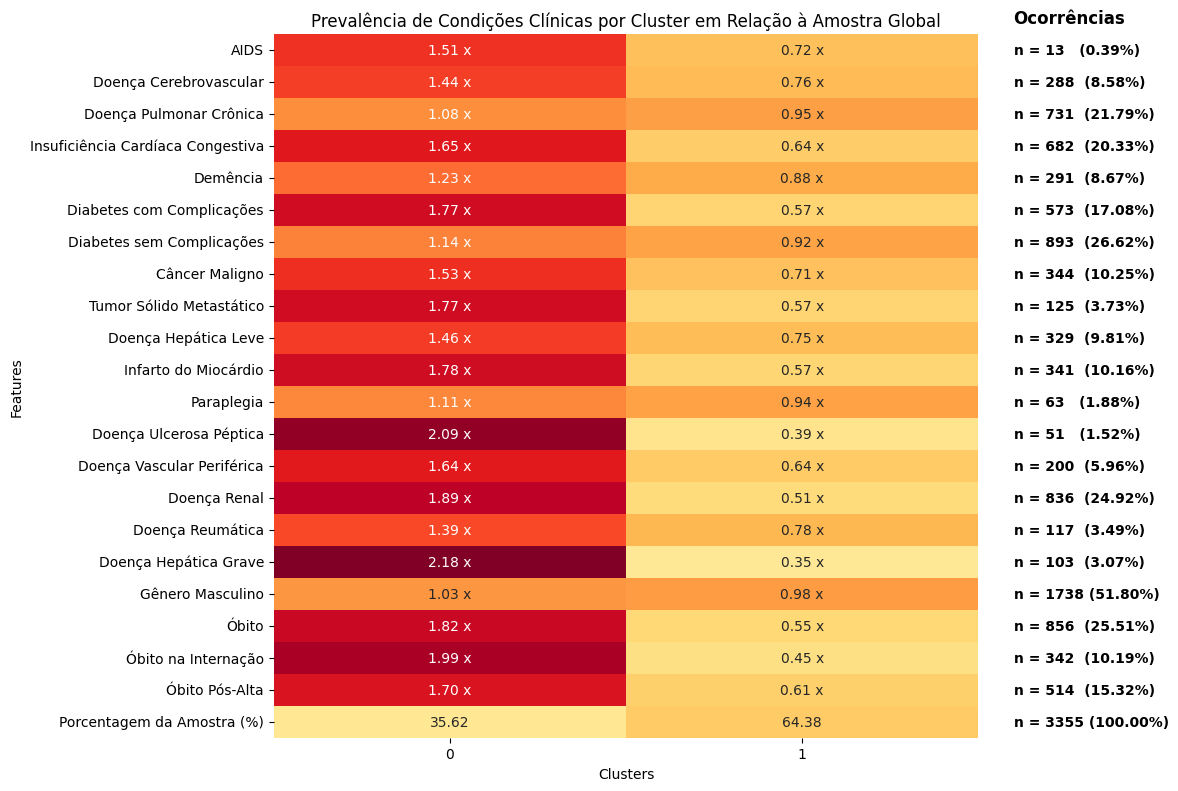

2026-02-24 18:36:02,882 - ClusterBaseModule - INFO - Created categorical heatmap: 22 features, 2 clusters


In [9]:
helper.heatmap_clusters_categorical(
    figsize=FIGSIZE_CLUSTER_HEATMAP,
    relative_total=True,
    # savepath=IMAGES_SAVE_PATH + "kmeans-all-categorical-relative"
)

In [10]:
selected_clusters = [0, 1]

In [11]:
helper.set_clustered_autoencoder()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:24<00:00,  4.01it/s]


2026-02-24 18:36:28,173 - ClusterBaseModule - INFO - Autoencoder clustering completed: 3355 records, embedding_size=2


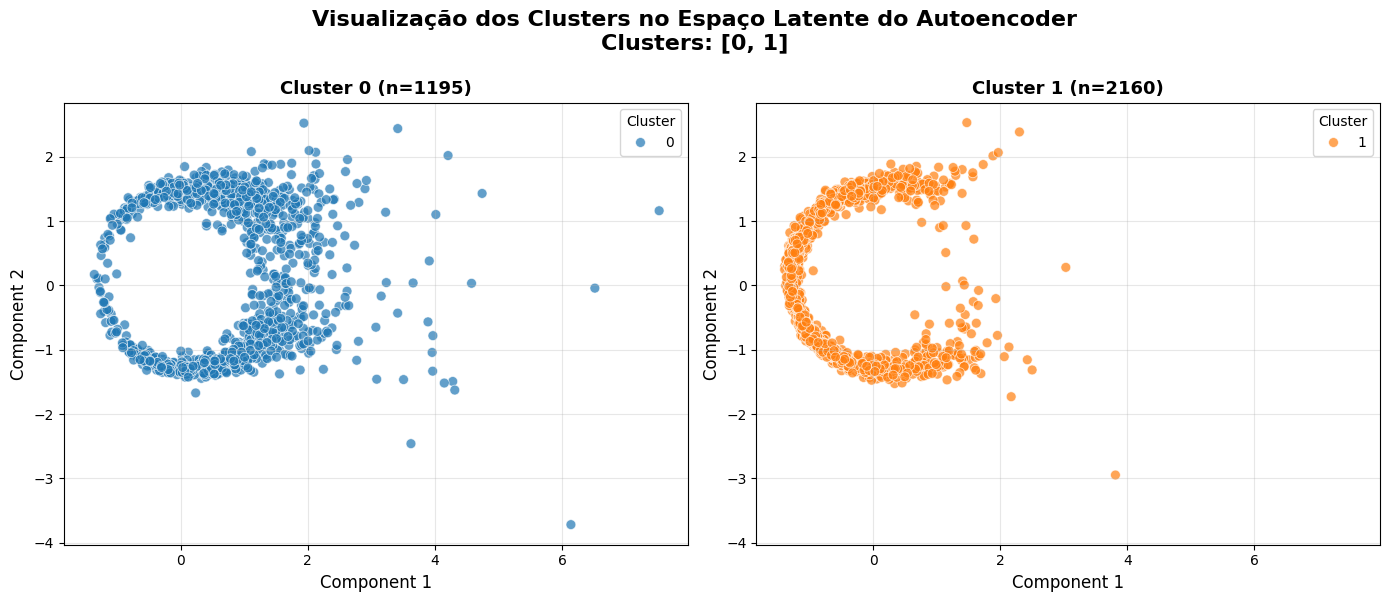

2026-02-24 18:37:58,556 - ClusterBaseModule - INFO - Displayed autoencoder clusters: 2 clusters


In [16]:
helper.show_clustered_autoencoder(
    selected_clusters=selected_clusters,
    # savepath=IMAGES_SAVE_PATH + "kmeans-all-autoencoder",
)

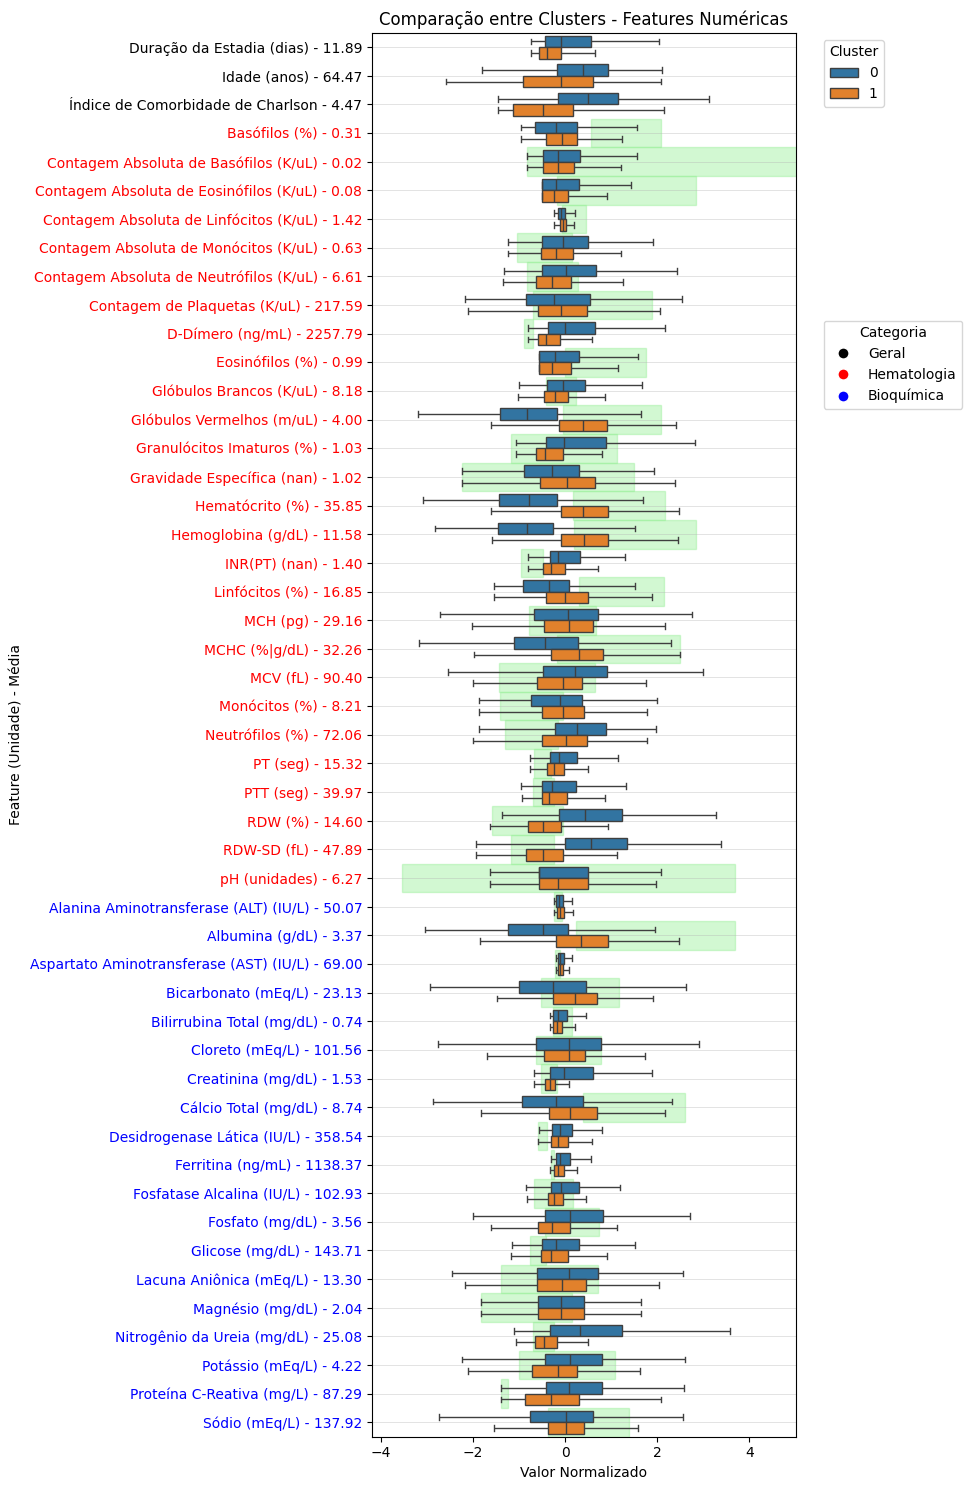

2026-02-19 14:39:32,448 - ClusterBaseModule - INFO - Displayed numerical comparison: 49 features, 2 clusters


[('Hemoglobin_Hematology_Blood_g/dL', np.float64(1.46643996839002e-228)),
 ('Red Blood Cells_Hematology_Blood_m/uL', np.float64(5.312271124869303e-203)),
 ('Hematocrit_Hematology_Blood_%', np.float64(4.033600773839714e-201)),
 ('RDW-SD_Hematology_Blood_fL', np.float64(2.8987574547521556e-190)),
 ('RDW_Hematology_Blood_%', np.float64(6.869243224133666e-160)),
 ('Urea Nitrogen_Chemistry_Blood_mg/dL', np.float64(1.6221446913641143e-148)),
 ('Creatinine_Chemistry_Blood_mg/dL', np.float64(1.9744646923890704e-122)),
 ('Albumin_Chemistry_Blood_g/dL', np.float64(9.610989511876596e-119)),
 ('charlson_comorbidity_index', np.float64(3.986048536270316e-112)),
 ('D-Dimer_Hematology_Blood_ng/mL|ng/mL FEU',
  np.float64(7.648311877491618e-76)),
 ('MCHC_Hematology_Blood_%|g/dL', np.float64(1.0158828469725353e-66)),
 ('Immature Granulocytes_Hematology_Blood_%',
  np.float64(5.880230538920184e-59)),
 ('length_of_stay_days', np.float64(9.207656622564546e-51)),
 ('Phosphate_Chemistry_Blood_mg/dL', np.floa

In [ ]:
helper.show_cluster_compare_numerical(
    selected_clusters=selected_clusters,
    figsize=(10, 15),
    # savepath=IMAGES_SAVE_PATH + "kmeans-all-numerical",
)

#### Future data


2026-02-19 14:39:32,470 - Modules.FutureAnalysisModule - WARNING - 84 subject_ids in target data are missing from reference data. These will be filtered out.
2026-02-19 14:39:32,476 - Modules.FutureAnalysisModule - WARNING - 551 subject_ids in target data are missing from reference data. These will be filtered out.
2026-02-19 14:39:32,497 - Modules.FutureAnalysisModule - INFO - Clusters inserted for 3649 records
2026-02-19 14:39:32,512 - Modules.FutureAnalysisModule - INFO - Auto-detected 19 binary features for analysis
2026-02-19 14:39:32,541 - Modules.FutureAnalysisModule - INFO - Delta clusters calculated for 1 clusters
2026-02-19 14:39:32,543 - Modules.FutureAnalysisModule - INFO - FutureAnalysisHelper initialized with 3355 past records and 2257 future records
2026-02-19 14:39:32,547 - Modules.FutureAnalysisModule - INFO - Clusters inserted for 976 records
2026-02-19 14:39:32,552 - Modules.FutureAnalysisModule - INFO - Auto-detected 20 binary features for analysis
2026-02-19 14:39:

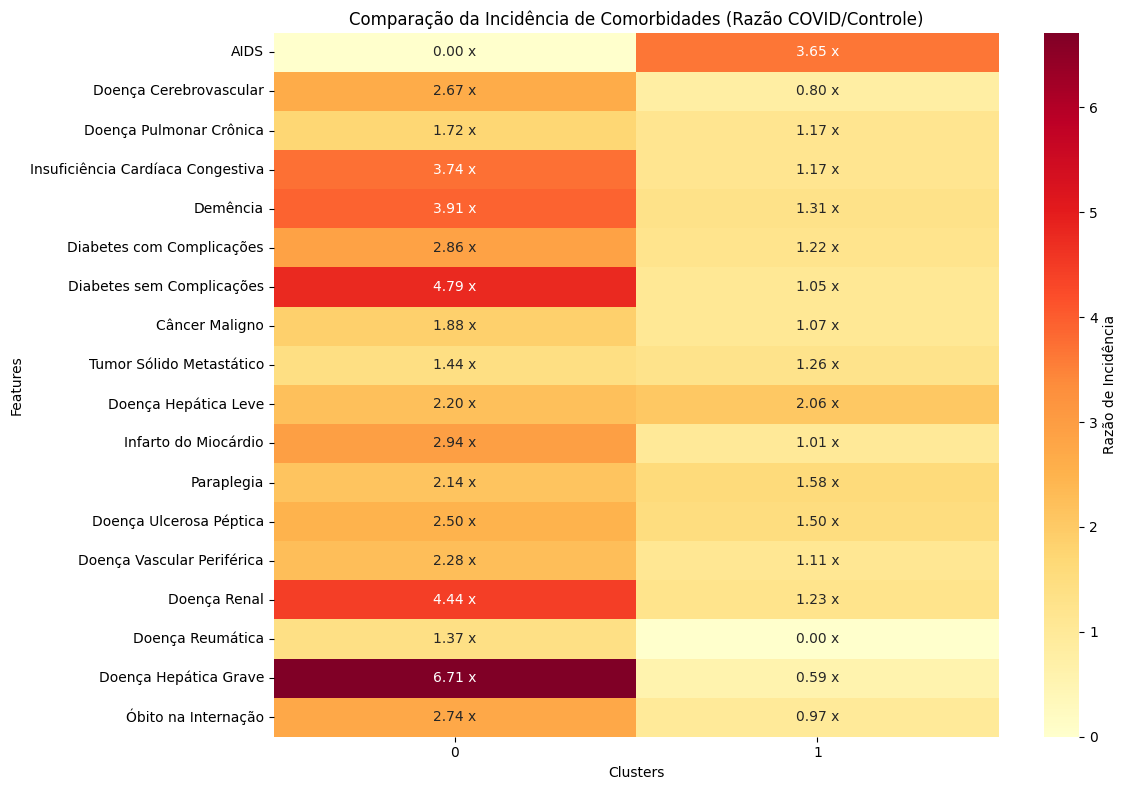

In [ ]:
future_helper = fa.FutureAnalysisHelper(
    helper.clustered_data, future_data, control, control_readmission
)
delta = future_helper.get_delta_clusters(percentage=True, relative_total=True)
future_helper.show_delta_heatmap(
    figsize=FIGSIZE_FUTURE_HEATMAP,
    relative_total=True,
    selected_clusters=selected_clusters,
    # savepath=IMAGES_SAVE_PATH + "kmeans-all-future",
)

In [ ]:
future_helper.get_mean_readmission()

2026-02-19 14:39:32,723 - Modules.FutureAnalysisModule - INFO - Clusters inserted for 2257 records
2026-02-19 14:39:32,726 - Modules.FutureAnalysisModule - INFO - Calculated mean readmission for 2 clusters


{'Mean readmission Cluster 0': np.float64(2.59),
 'Mean readmission Cluster 1': np.float64(2.11),
 'Overall Mean readmission': 2.31}

In [ ]:
future_helper.get_mean_days_gap()

2026-02-19 14:39:32,738 - Modules.FutureAnalysisModule - INFO - Clusters inserted for 976 records
2026-02-19 14:39:32,741 - Modules.FutureAnalysisModule - INFO - Calculated mean days gap for 2 clusters


{'Mean days gap Cluster 0': np.float64(119.22),
 'Mean days gap Cluster 1': np.float64(133.48),
 'Overall Mean days gap': 127.49}

In [ ]:
future_helper.get_mortality_rates(only_first_admission=True)

2026-02-19 14:39:32,767 - Modules.FutureAnalysisModule - INFO - Clusters inserted for 976 records
2026-02-19 14:39:32,783 - Modules.FutureAnalysisModule - INFO - Calculated mortality rates for 2 clusters


{'Mortality rate Cluster 0': 0.07,
 'Mortality rate Cluster 1': 0.13,
 'Overall Mortality rate': 0.09}

# Add log

In [ ]:
# log_file = "../log.csv"
# current_dir = os.getcwd()
# log_file_path = os.path.join(current_dir, log_file)

# # Add line to save log
# if os.path.exists(log_file_path):
#     with open(log_file_path, 'a') as f:
#         f.write(f"K-means, None, Comprehensive, {metrics['disco']}, {metrics['dbcv']}, {metrics['dsi']}, {metrics['silhouette']}\n")